# Generation, oversampling, and traceability

Generate synthetic rows and inspect their trace records.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from mimic import MIMIC, GenerationPolicy, ResNetEncoder, ForestConditionalSampler

rng = np.random.default_rng(2)

def make_spiral(label, n, phase, noise=0.12):
    theta = np.linspace(0.45, 4.8 * np.pi, n)
    radius = np.linspace(0.25, 4.0, n)
    x = radius * np.cos(theta + phase) + rng.normal(0, noise, n)
    y = radius * np.sin(theta + phase) + rng.normal(0, noise, n)
    return pd.DataFrame({"x": x, "y": y, "label": label})

major = make_spiral("majority", 180, phase=0.0)
minor_full = make_spiral("minority", 180, phase=np.pi)
minor = minor_full.sample(n=90, random_state=2).sort_index().reset_index(drop=True)

df = pd.concat([major, minor], ignore_index=True)
df["id"] = np.arange(len(df))

display(df["label"].value_counts().rename_axis("label").to_frame("count").style.set_caption("Original class balance"))
display(df.head(8).style.set_caption("Original two-spiral training rows"))


,count
label,
majority,180
minority,90


,x,y,label,id
0,0.247798,0.205585,majority,0
1,0.170810,0.004947,majority,1
2,0.189107,0.061862,majority,2
3,-0.052729,0.212612,majority,3
4,0.453989,0.205364,majority,4
5,0.369114,0.451555,majority,5
6,0.182417,0.392399,majority,6
7,0.299736,0.304533,majority,7


In [9]:
mimic = MIMIC(
    ignore_columns=["id"],
    regression_columns=["x", "y"],
    classification_columns=["label"],
    encoder=ResNetEncoder(embedding_dim=16, hidden_dim=64, n_layers=4, dropout=0.05, max_epochs=30, patience=5, batch_size=64, random_state=2),
    decoder=ForestConditionalSampler(n_estimators=120, random_state=2),
    policy=GenerationPolicy(method="displacement", neighbour_mode="mutual", n_neighbors=5, lambda_range=(0.25, 0.75)),
    n_bootstrap=1,
    random_state=2,
)
mimic.fit(df)
synthetic, trace = mimic.sample(12, return_trace=True)

display(synthetic.head(8).style.set_caption("Displacement-generated sample rows"))
display(trace.head(8).style.set_caption("Displacement generation trace"))


,x,y,label
0,2.435643,-0.150861,minority
1,-0.299602,-2.108982,minority
2,-1.304455,-2.108982,minority
3,0.001773,0.572650,majority
4,1.270134,1.568991,majority
5,-2.653632,-0.712739,majority
6,0.879876,-1.420213,majority
7,-0.357606,-0.547104,minority


,trace_type,sample_index,method,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,restriction,condition,decoder,random_state,sweep,column,task,sampled_value,conditioning,embedding_slice_start,embedding_slice_stop,member_index,source_position,source_index,source_weight,leaf_support_size,sampled_class_code,class_probabilities
0,embedding,0,displacement,226.000000,225.000000,226.000000,0.399246,mutual,basic,None,ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,embedding,1,displacement,219.000000,218.000000,219.000000,0.550050,mutual,basic,None,ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,embedding,2,displacement,219.000000,221.000000,219.000000,0.343951,mutual,basic,None,ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
3,embedding,3,displacement,14.000000,12.000000,11.000000,0.578717,mutual,basic,None,ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
4,embedding,4,displacement,82.000000,81.000000,83.000000,0.325031,mutual,basic,None,ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
5,embedding,5,displacement,116.000000,115.000000,113.000000,0.461392,mutual,basic,None,ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
6,embedding,6,displacement,59.000000,55.000000,59.000000,0.733718,mutual,basic,None,ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
7,embedding,7,displacement,184.000000,183.000000,185.000000,0.343626,mutual,basic,None,ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


In [10]:
minority_needed = df["label"].value_counts()["majority"] - df["label"].value_counts()["minority"]
minority_synthetic, minority_trace = mimic.sample(
    minority_needed,
    condition={"label": "minority"},
    return_trace=True,
)
balanced = pd.concat([df.drop(columns=["id"]), minority_synthetic], ignore_index=True)

display(balanced["label"].value_counts().rename_axis("label").to_frame("count").style.set_caption("Class balance after minority-conditioned displacement oversampling"))
display(minority_synthetic.head(8).style.set_caption("Synthetic minority spiral rows"))
display(minority_trace.head(8).style.set_caption("Minority-conditioned oversampling trace"))


,count
label,
majority,180
minority,180


,x,y,label
0,-3.093082,-1.582583,minority
1,-3.311947,-0.838127,minority
2,-3.409350,-0.269788,minority
3,-0.357606,-0.611168,minority
4,-1.250382,1.302956,minority
5,-1.051137,-1.478812,minority
6,0.805947,-0.016618,minority
7,-2.701565,-2.740668,minority


,trace_type,sample_index,method,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,restriction,condition,decoder,random_state,sweep,column,task,sampled_value,conditioning,embedding_slice_start,embedding_slice_stop,member_index,source_position,source_index,source_weight,leaf_support_size
0,embedding,0,displacement,255.000000,254.000000,252.000000,0.399246,mutual,basic,"{""label"": ""minority""}",ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,embedding,1,displacement,253.000000,251.000000,252.000000,0.550050,mutual,basic,"{""label"": ""minority""}",ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,embedding,2,displacement,253.000000,255.000000,252.000000,0.343951,mutual,basic,"{""label"": ""minority""}",ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
3,embedding,3,displacement,184.000000,183.000000,185.000000,0.578717,mutual,basic,"{""label"": ""minority""}",ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
4,embedding,4,displacement,207.000000,205.000000,206.000000,0.325031,mutual,basic,"{""label"": ""minority""}",ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
5,embedding,5,displacement,218.000000,216.000000,218.000000,0.461392,mutual,basic,"{""label"": ""minority""}",ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
6,embedding,6,displacement,199.000000,200.000000,199.000000,0.733718,mutual,basic,"{""label"": ""minority""}",ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
7,embedding,7,displacement,258.000000,259.000000,260.000000,0.445812,mutual,basic,"{""label"": ""minority""}",ForestConditionalSampler,2.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


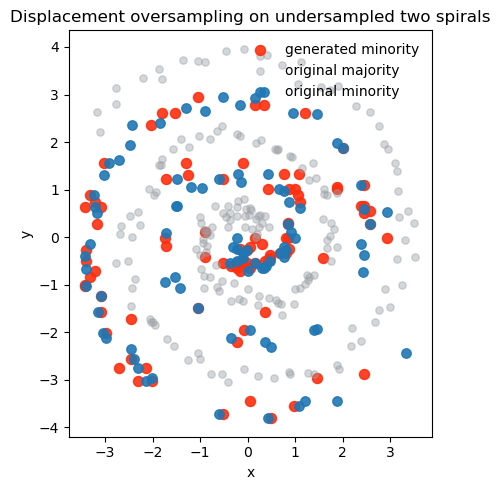

In [14]:
plot_df = pd.concat(
    [
        df.drop(columns=["id"]).assign(source="original"),
        minority_synthetic.assign(source="generated"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(6, 5))
for (source, label), part in plot_df.groupby(["source", "label"]):
    if source == "original" and label == "majority":
        color, marker, alpha, size = "#9aa0a6", "o", 0.42, 28
    elif source == "original" and label == "minority":
        color, marker, alpha, size = "#1f77b4", "o", 0.9, 46
    else:
        color, marker, alpha, size = "#ff2e0e", "o", 0.9, 52
    ax.scatter(part["x"], part["y"], label=f"{source} {label}", color=color, marker=marker, alpha=alpha, s=size)
ax.set_title("Displacement oversampling on undersampled two spirals")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.legend(frameon=False)
fig.tight_layout()


## Identity-space configurable baseline

Set the full MIMIC estimator here, using `IdentityEncoder` and `IdentityDecoder` to generate in the preprocessed original feature space. Change `identity_policy` to switch between SMOTE-style interpolation and displacement.

,method,neighbour_mode,n_neighbors,lambda_range,n_generated,trace_rows,x_min,x_max,y_min,y_max
0,displacement,mutual,5,"(0.25, 0.75)",90,90,-3.660477,3.039411,-3.330662,3.034946


,x,y,label
0,-3.280016,-0.852275,minority
1,-3.660477,-0.669908,minority
2,-3.558439,-0.826417,minority
3,-0.372758,-0.393076,minority
4,-0.322907,3.034946,minority
5,-2.875262,1.809138,minority
6,-1.375632,-1.236015,minority
7,-3.104444,-2.014176,minority


,trace_type,sample_index,method,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,restriction,condition,decoder,random_state
0,embedding,0,displacement,255,254,252,0.399246,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
1,embedding,1,displacement,253,251,252,0.550050,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
2,embedding,2,displacement,253,255,258,0.343951,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
3,embedding,3,displacement,184,187,185,0.387485,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
4,embedding,4,displacement,239,240,238,0.325031,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
5,embedding,5,displacement,247,248,245,0.584649,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
6,embedding,6,displacement,218,217,216,0.733718,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
7,embedding,7,displacement,258,260,261,0.445812,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2


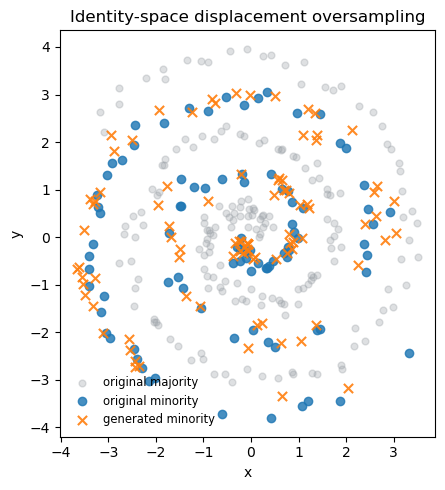

In [12]:
import sys
from pathlib import Path

from mimic import IdentityDecoder, IdentityEncoder

notebook_dir = Path.cwd() / "notebooks" if (Path.cwd() / "notebooks").exists() else Path.cwd()
if str(notebook_dir) not in sys.path:
    sys.path.append(str(notebook_dir))

from mimic_notebook_utils import identity_generation_plot

identity_policy = GenerationPolicy(
    method="displacement",  # change to "displacement" for the displacement variant
    neighbour_mode="mutual",
    n_neighbors=5,
    lambda_range=(0.25, 0.75),
)

identity_mimic = MIMIC(
    ignore_columns=["id"],
    regression_columns=["x", "y"],
    classification_columns=["label"],
    encoder=IdentityEncoder(),
    decoder=IdentityDecoder(),
    policy=identity_policy,
    n_bootstrap=1,
    random_state=2,
)

identity_summary, identity_synthetic, identity_trace, identity_fig, identity_ax = identity_generation_plot(
    identity_mimic,
    df,
    n_samples=minority_needed,
    condition={"label": "minority"},
    title=f"Identity-space {identity_policy.method} oversampling",
)

display(identity_summary.style.set_caption("Identity-space generation summary"))
display(identity_synthetic.head(8).style.set_caption("Identity-space synthetic minority rows"))
display(identity_trace.head(8).style.set_caption("Identity-space generation trace"))